<a href="https://colab.research.google.com/github/trishitsingla/cricket-analytics/blob/main/01_batter_phase_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/Cricket Analytics/deliveries.csv")

df.head()

/tmp/ipykernel_32205/1208099816.py:3: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("/content/drive/MyDrive/Cricket Analytics/deliveries.csv")


,match_id,match_type,city,event,start_date,end_date,gender,inning,batting_team,over,...,runs_batter,runs_extras,runs_total,wides,noballs,byes,legbyes,penalty,is_ball_faced,wicket
0,438938,MDM,Nairobi,ICC Intercontinental Shield,2010-02-20,2010-02-23,male,1,Netherlands,0,...,1,0,1,0,0,0,0,0,1,0
1,438938,MDM,Nairobi,ICC Intercontinental Shield,2010-02-20,2010-02-23,male,1,Netherlands,0,...,0,1,1,0,0,0,1,0,1,0
2,438938,MDM,Nairobi,ICC Intercontinental Shield,2010-02-20,2010-02-23,male,1,Netherlands,0,...,0,0,0,0,0,0,0,0,1,0
3,438938,MDM,Nairobi,ICC Intercontinental Shield,2010-02-20,2010-02-23,male,1,Netherlands,0,...,4,0,4,0,0,0,0,0,1,0
4,438938,MDM,Nairobi,ICC Intercontinental Shield,2010-02-20,2010-02-23,male,1,Netherlands,0,...,0,0,0,0,0,0,0,0,1,0


In [2]:
df.shape

(10929267, 23)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10929267 entries, 0 to 10929266
Data columns (total 23 columns):
 #   Column         Dtype 
---  ------         ----- 
 0   match_id       object
 1   match_type     object
 2   city           object
 3   event          object
 4   start_date     object
 5   end_date       object
 6   gender         object
 7   inning         int64 
 8   batting_team   object
 9   over           int64 
 10  ball           int64 
 11  batter         object
 12  bowler         object
 13  runs_batter    int64 
 14  runs_extras    int64 
 15  runs_total     int64 
 16  wides          int64 
 17  noballs        int64 
 18  byes           int64 
 19  legbyes        int64 
 20  penalty        int64 
 21  is_ball_faced  int64 
 22  wicket         int64 
dtypes: int64(13), object(10)
memory usage: 1.9+ GB


In [4]:
df['match_type'].value_counts()

,count
match_type,
MDM,3547575
T20,2984022
Test,1737843
ODI,1639711
ODM,949208
IT20,70908


In [5]:
import numpy as np

# Define all possible conditions
conditions = [
    df['match_type'].isin(['ODI', 'ODM']) & (df['over'] < 10),
    df['match_type'].isin(['ODI', 'ODM']) & (df['over'] >= 10) & (df['over'] < 40),
    df['match_type'].isin(['ODI', 'ODM']) & (df['over'] >= 40),

    df['match_type'].isin(['T20', 'IT20', 'T20I']) & (df['over'] < 6),
    df['match_type'].isin(['T20', 'IT20', 'T20I']) & (df['over'] >= 6) & (df['over'] < 15),
    df['match_type'].isin(['T20', 'IT20', 'T20I']) & (df['over'] >= 15)
]

# Define the corresponding outputs for those conditions
choices = [
    "powerplay", "middle", "death",
    "powerplay", "middle", "death"
]

# Map them together, with "Test" as the fallback
df["phase"] = np.select(conditions, choices, default="Test")

In [6]:
df["boundary"] = df["runs_batter"].apply(lambda x: 1 if x >= 4 else 0)

In [7]:
def top_strikers(df: pd.DataFrame, phase: str, format: str, threshold_balls: int = 200) -> pd.DataFrame:
  if phase == 'all':
    filtered_df = df[(df["match_type"] == format)]
  else:
    filtered_df = df[(df["phase"] == phase) & (df["match_type"] == format)]

  batter_phase = (
      filtered_df.groupby(["batter","phase"])
      .agg(
          runs=("runs_batter","sum"),
          balls=("is_ball_faced","sum")
      )
      .reset_index()
  )
  batter_phase["strike_rate"] = 100 * batter_phase["runs"] / batter_phase["balls"]
  boundary_stats = (
    filtered_df.groupby(["batter","phase"])
    .agg(boundaries=("boundary","sum"))
    .reset_index()
  )
  batter_phase = batter_phase.merge(boundary_stats, on=["batter","phase"])

  batter_phase["boundary_pct"] = batter_phase["boundaries"] / batter_phase["balls"]

  batter_phase = batter_phase[batter_phase["balls"] > threshold_balls]
  table = batter_phase.pivot(
    index="batter",
    columns="phase",
    values="strike_rate"
  )
  if phase == 'all':
    return table.sort_values(by="death", ascending=False)
  else:
    return table.sort_values(by=phase, ascending=False)

In [8]:
top_strikers(df, "powerplay", 'T20', 200)

phase,powerplay
batter,
MJ Owen,195.177665
Faisal Khan,181.724138
FH Allen,170.439351
Abbas Ghani,169.483568
Shahid Afridi,168.013468
...,...
L Agatha,49.099099
MLN Sissako,47.104247
GK Diviya,46.570397


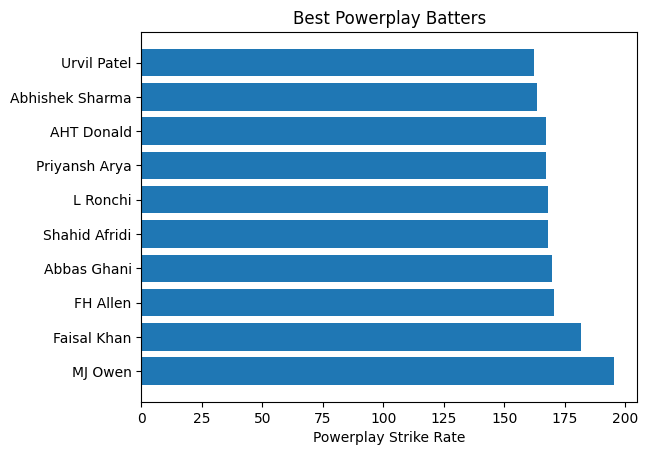

In [9]:
import matplotlib.pyplot as plt
phase = "powerplay"

top = top_strikers(df, phase, 'T20', 200).head(10)

plt.barh(top.index, top[phase])
plt.xlabel(f"{phase.capitalize()} Strike Rate")
plt.title(f"Best {phase.capitalize()} Batters")
plt.show()